# Classical Alexander duality to find representative cycles
Without relative subdivision/tight supplement

In [24]:
import numpy as np
import pandas as pd
import gudhi
import matplotlib.pyplot as plt
import itertools
from itertools import combinations
import networkx as nx

from gudhi import AlphaComplex as AC

In [6]:
from src.abstract_subdivision import AbstractSubdivision

Subs = {i: AbstractSubdivision(i) for i in range(2,5)}

from src.relative_subdivision import subdivision, RelAbsSub, RelSub
from src.alpha_builder import AlphaComplex, getAlphaComplex
from src.visualization import draw_2d_simplicial_complex, draw_Sup

#### Relative subdivision

In [7]:
def relative_subdivide_complex(M, pointsM, L, pointsL, Subs):
    
    relM, relPoints = RelSub(M, pointsM, L, pointsL, Subs)
    
    # L simplices are unchanged in relative subdivision
    sL = L.copy()
    sPointsL = pointsL.copy()
    
    return relM, relPoints, sL, sPointsL

#### Computing the outer boundary 
i.e. the point at infinity

In [8]:
def compute_outer_boundary(sM):
    
    edges = sorted([s for s in sM if len(s) == 2])
    triangles = sorted([s for s in sM if len(s) == 3])
    
    edge_index = {tuple(e): i for i, e in enumerate(edges)}
    
    boundary_count = np.zeros(len(edges), dtype=int)
    
    for T in triangles:
        for e in [(T[0],T[1]), (T[1],T[2]), (T[0],T[2])]:
            boundary_count[edge_index[tuple(sorted(e))]] += 1
    
    boundary_mod2 = boundary_count % 2
    
    marked_edges = [
        edges[i]
        for i in range(len(edges))
        if boundary_mod2[i] == 1
    ]
    
    return marked_edges

#### The tight supplement

In [9]:
def compute_tight_supplement(relM, relPoints, pointsL):
    
    n_L_vertices = pointsL.shape[0]
    
    # These are exactly the L vertices
    SubComplexIndices = list(range(n_L_vertices))
    
    # Keep simplices not touching L
    Lbar = [
        simplex for simplex in relM
        if all(v >= n_L_vertices for v in simplex)
    ]
    
    # Explicit 0-simplices
    verticesLbar = [
        [i] for i in range(n_L_vertices, relPoints.shape[0])
    ]
    
    Lbar = verticesLbar + Lbar
    
    return Lbar, SubComplexIndices

#### Union find for connected components

In [10]:
def connected_components(Lbar):
    
    vertices = [s[0] for s in Lbar if len(s) == 1]
    edges = [s for s in Lbar if len(s) == 2]
    
    parent = {v: v for v in vertices}
    
    def find(v):
        while parent[v] != v:
            parent[v] = parent[parent[v]]
            v = parent[v]
        return v
    
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra
    
    for e in edges:
        union(e[0], e[1])
    
    components = {}
    for v in vertices:
        root = find(v)
        components.setdefault(root, []).append(v)
    
    return list(components.values())

#### Exclude CC that touch on the boundary

In [11]:
def discard_boundary_components(CC, markedEdges):
    
    boundary_vertices = set()
    for e in markedEdges:
        boundary_vertices.update(e)
    
    valid = []
    excluded = []
    
    for c in CC:
        if any(v in boundary_vertices for v in c):
            excluded.append(c)
        else:
            valid.append(c)
    
    return valid, excluded

#### Extract representative cycles

In [12]:
def extract_representatives_relative(validCC, MminusL, pointsL, M):
    
    offset = pointsL.shape[0]
    
    edges = sorted([s for s in M if len(s) == 2])
    edge_index = {tuple(e): i for i,e in enumerate(edges)}
    
    repr_edges = []
    
    for comp in validCC:
        
        repr_triangles = []
        
        for v in comp:
            if v >= offset:
                simplex = MminusL[v - offset]   # <-- FIX HERE
                if len(simplex) == 3:
                    repr_triangles.append(simplex)
        
        boundary_count = np.zeros(len(edges), dtype=int)
        
        for T in repr_triangles:
            for e in [(T[0],T[1]), (T[0],T[2]), (T[1],T[2])]:
                boundary_count[edge_index[tuple(sorted(e))]] += 1
        
        boundary_mod2 = boundary_count % 2
        
        repr_edges.extend([
            edges[i]
            for i in range(len(edges))
            if boundary_mod2[i] == 1
        ])
    
    return repr_edges

## Experiment

In [13]:
Subs = {i: AbstractSubdivision(i) for i in range(2,5)}

In [15]:
df = pd.read_csv('pointclouds_rat_brain_no_myelin0_image.csv')

In [16]:
points = df.to_numpy()[:,1:]

In [17]:
points.shape

(53096, 2)

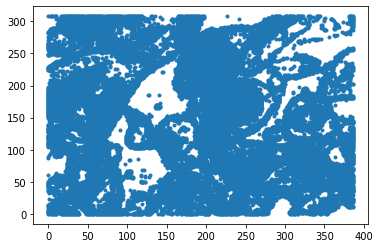

In [18]:
plt.plot(points[:,0], points[:,1], '.')

In [19]:
# Bounding box
mins = points.min(axis=0)
maxs = points.max(axis=0)

# Midpoints
mids = (mins + maxs) / 2

mask = (
    (points[:, 0] <= mids[0]) &
    (points[:, 1] <= mids[1])
)

points_subset = points[mask]

# Subsampling: keep 1 out of every 10 points
points_subsampled = points_subset[::10]


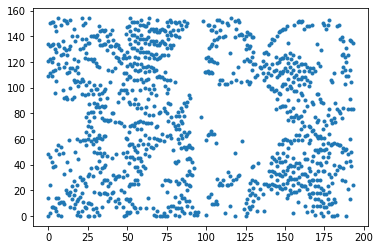

In [20]:
plt.plot(points_subsampled[:,0], points_subsampled[:,1], '.')

In [21]:
points_subsampled.shape

(1217, 2)

In [22]:
points_subsampled *= 0.05

In [25]:
ac = gudhi.AlphaComplex(points=points_subsampled)
st = ac.create_simplex_tree()

# Compute persistence
diag = st.persistence()

In [26]:
pd0 = [x[1] for x in diag if x[0] == 0]
pd1 = [x[1] for x in diag if x[0] == 1]

/home/marco/.local/lib/python3.10/site-packages/gudhi/persistence_graphical_tools.py:112: UserWarning: usetex mode requires dvipng.
  warnings.warn("usetex mode requires dvipng.")


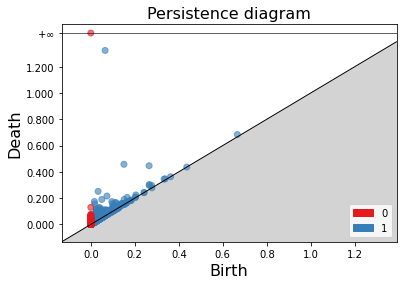

In [27]:
gudhi.plot_persistence_diagram(diag)
plt.show()

In [28]:
L = getAlphaComplex(points_subsampled, .5)

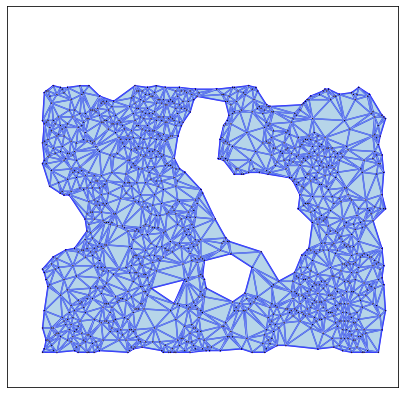

In [29]:
draw_2d_simplicial_complex(L, points_subsampled)

In [30]:
M = getAlphaComplex(points_subsampled, 1.2)

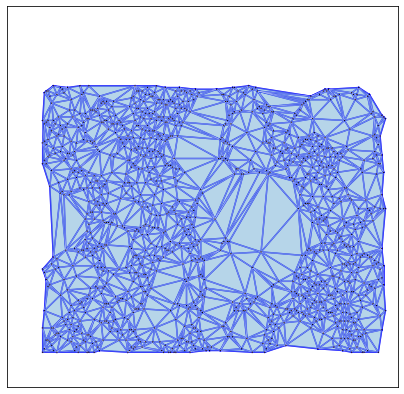

In [31]:
draw_2d_simplicial_complex(M, points_subsampled)

In [92]:
MminusL = [ x for x in M if x not in L ]

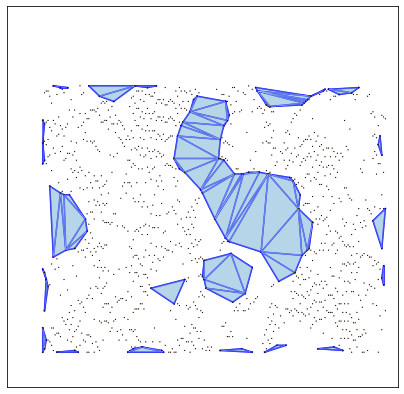

In [93]:
draw_2d_simplicial_complex(MminusL, points_subsampled)

In [33]:
sM, sPointsM, sL, sPointsL = relative_subdivide_complex(M, points_subsampled, L, points_subsampled, Subs)

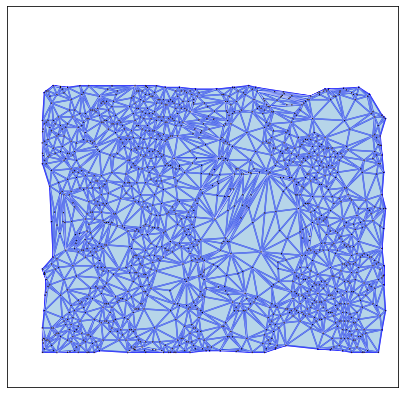

In [37]:
draw_2d_simplicial_complex(sM, pos=sPointsM)

### Compute outer boundary

In [38]:
outer_edges = compute_outer_boundary(sM)

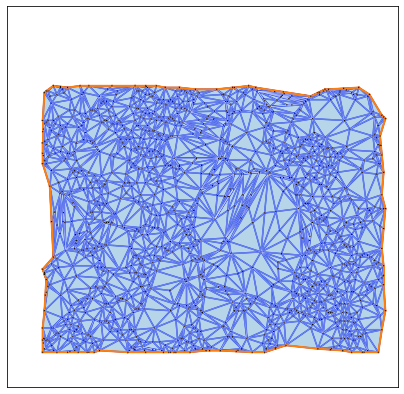

In [41]:
draw_2d_simplicial_complex(sM, sPointsM, markedEdges=outer_edges)

### Compute supplement

In [42]:
Lbar, SubComplexIndices = compute_tight_supplement(sM, sPointsM, sPointsL)

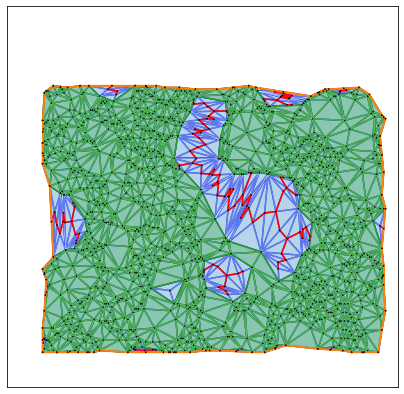

In [44]:
draw_Sup( sM , sL , Lbar, SubComplexIndices, pos = sPointsM, posSub = sPointsL, boundaryComponent = outer_edges )

### Connected components of $\bar{L}$

In [45]:
CC = connected_components(Lbar)

### Remove boundary connected components

In [46]:
validCC, excludedCC = discard_boundary_components(CC, outer_edges)

### Get list of excluded vertices

In [47]:
excludedVerts = [v for CC in excludedCC for v in CC]

### Plot

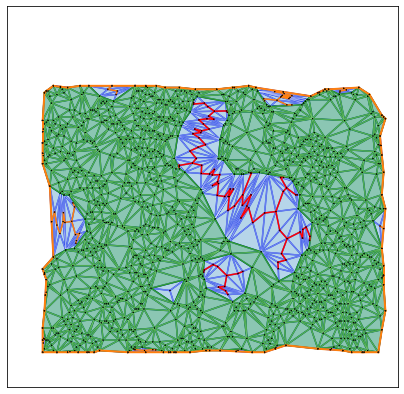

In [48]:
draw_Sup( sM , sL , Lbar, SubComplexIndices, pos = sPointsM, posSub = sPointsL, boundaryComponent = outer_edges, excludedVerts=excludedVerts)

### Representative cycles

In [50]:
MminusL = [ x for x in M if x not in L ] # M minus L

In [52]:
repr_edges = extract_representatives_relative(validCC, MminusL,points_subsampled,M)

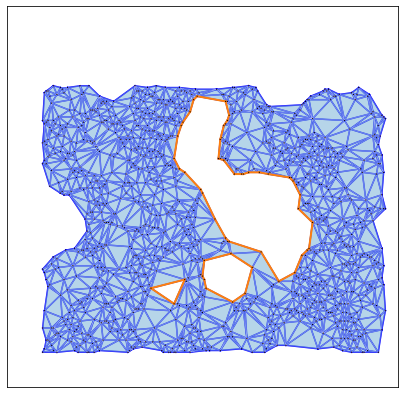

In [54]:
draw_2d_simplicial_complex(L,pos=points_subsampled, markedEdges=repr_edges)